# Manex Data Understanding Notebook

This notebook is a guided walkthrough of the hackathon dataset.

It helps you:
- connect to your team database,
- validate the dataset shape,
- understand high-level quality signals,
- and inspect the 4 documented root-cause stories from `docs/DATA_PATTERNS.md`.


## 0) One-time setup

1. Create a virtual environment (recommended).
2. Install dependencies:

```bash
pip install pandas sqlalchemy psycopg2-binary python-dotenv matplotlib seaborn
```

3. Copy `notebook.env.example` to `.env` and fill in your values from your team handout.
4. Restart kernel if you just installed packages.


In [2]:
from __future__ import annotations

import os
from typing import Optional

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

load_dotenv()


True

In [3]:
MANEX_PG_URL = os.getenv("MANEX_PG_URL")
MANEX_ASSETS_BASE_URL = os.getenv("MANEX_ASSETS_BASE_URL", "").rstrip("/")

if not MANEX_PG_URL:
    raise ValueError(
        "Missing MANEX_PG_URL. Copy notebook.env.example to .env and set your team Postgres URL."
    )

engine = create_engine(MANEX_PG_URL)
print("Database connection configured.")
print(f"Assets base URL configured: {bool(MANEX_ASSETS_BASE_URL)}")


Database connection configured.
Assets base URL configured: True


In [4]:
def q(sql: str, params: Optional[dict] = None) -> pd.DataFrame:
    """Run SQL and return a DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn, params=params)


## 1) Sanity check: row counts + time window

This gives you a quick sense of dataset size and expected time horizon.


In [5]:
row_counts = q(
    """
    SELECT 'product' AS table_name, count(*) AS rows FROM product
    UNION ALL SELECT 'defect', count(*) FROM defect
    UNION ALL SELECT 'field_claim', count(*) FROM field_claim
    UNION ALL SELECT 'test_result', count(*) FROM test_result
    UNION ALL SELECT 'rework', count(*) FROM rework
    UNION ALL SELECT 'product_action', count(*) FROM product_action
    ORDER BY rows DESC;
    """
)
row_counts


,table_name,rows
0,test_result,2000
1,product,500
2,defect,150
3,rework,120
4,product_action,50
5,field_claim,40


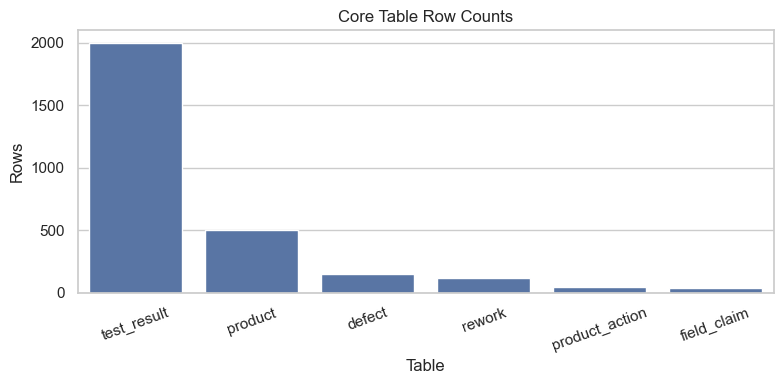

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=row_counts, x="table_name", y="rows", ax=ax)
ax.set_title("Core Table Row Counts")
ax.set_xlabel("Table")
ax.set_ylabel("Rows")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [7]:
time_window = q(
    """
    SELECT
      min(build_ts)::date AS min_build_date,
      max(build_ts)::date AS max_build_date,
      min(ts)::date AS min_defect_date,
      max(ts)::date AS max_defect_date,
      min(claim_ts)::date AS min_claim_date,
      max(claim_ts)::date AS max_claim_date
    FROM product
    CROSS JOIN defect
    CROSS JOIN field_claim;
    """
)
time_window


,min_build_date,max_build_date,min_defect_date,max_defect_date,min_claim_date,max_claim_date
0,2025-10-01,2026-03-31,2025-10-04,2026-04-03,2025-12-13,2026-04-03


Closest claim analog to the defect Pareto is a breakdown by `reported_part_number`, since `field_claim` does not appear to have a dedicated claim category/code column.

In [19]:
claims_pareto = q(
    """
    SELECT
      COALESCE(reported_part_number, '(missing reported part)') AS claim_bucket,
      count(*) AS cnt
    FROM field_claim
    GROUP BY 1
    ORDER BY cnt DESC, claim_bucket;
    """
)
claims_pareto["pct"] = claims_pareto["cnt"] / claims_pareto["cnt"].sum()
claims_pareto["cum_pct"] = claims_pareto["pct"].cumsum()
claims_pareto.head(10)


,claim_bucket,cnt,pct,cum_pct
0,PM-00008,14,0.350,0.350
1,PM-00002,5,0.125,0.475
2,PM-00015,5,0.125,0.600
3,PM-00009,4,0.100,0.700
4,PM-00016,4,0.100,0.800
5,PM-00007,3,0.075,0.875
6,PM-00001,1,0.025,0.900
7,PM-00004,1,0.025,0.925
8,PM-00006,1,0.025,0.950
9,PM-00017,1,0.025,0.975


## 2) Baseline quality view

Weekly trend and Pareto view before drilling into each story.


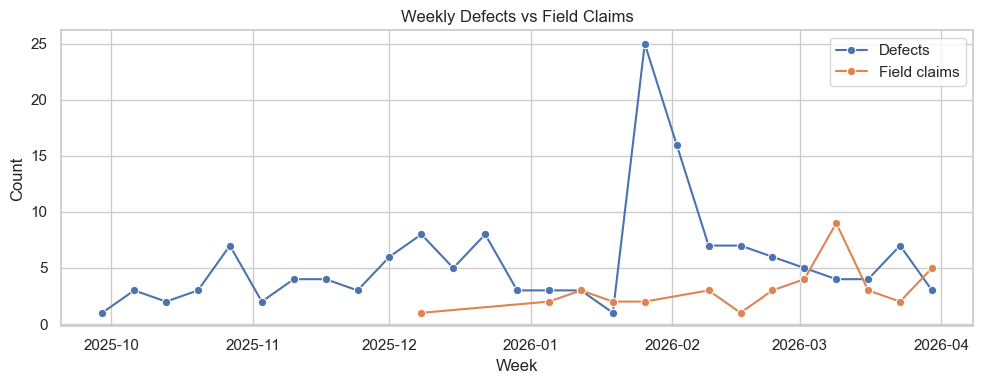

In [8]:
weekly = q(
    """
    SELECT
      date_trunc('week', defect_ts)::date AS week_start,
      count(*) AS defect_count,
      sum(cost) AS defect_cost
    FROM v_defect_detail
    GROUP BY 1
    ORDER BY 1;
    """
)

claims_weekly = q(
    """
    SELECT
      date_trunc('week', claim_ts)::date AS week_start,
      count(*) AS claim_count
    FROM v_field_claim_detail
    GROUP BY 1
    ORDER BY 1;
    """
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=weekly, x="week_start", y="defect_count", marker="o", label="Defects", ax=ax)
sns.lineplot(data=claims_weekly, x="week_start", y="claim_count", marker="o", label="Field claims", ax=ax)
ax.set_title("Weekly Defects vs Field Claims")
ax.set_xlabel("Week")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


In [9]:
pareto = q(
    """
    SELECT defect_code, count(*) AS cnt
    FROM defect
    GROUP BY defect_code
    ORDER BY cnt DESC;
    """
)
pareto["pct"] = pareto["cnt"] / pareto["cnt"].sum()
pareto["cum_pct"] = pareto["pct"].cumsum()
pareto.head(10)


,defect_code,cnt,pct,cum_pct
0,SOLDER_COLD,41,0.273333,0.273333
1,LABEL_MISALIGN,22,0.146667,0.420000
2,VIB_FAIL,20,0.133333,0.553333
3,VISUAL_CRACK,17,0.113333,0.666667
4,TEST_OOL,15,0.100000,0.766667
5,VISUAL_SCRATCH,12,0.080000,0.846667
6,COLD_JOINT,5,0.033333,0.880000
7,DIM_OOL,4,0.026667,0.906667
8,THERMAL_DRIFT,3,0.020000,0.926667
9,MISSING_PART,3,0.020000,0.946667


## 3) Story 1: Supplier incident (`SB-00007`)

Expected signature: `SOLDER_COLD` around batch `SB-00007` / part `PM-00008`.


In [10]:
story1 = q(
    """
    WITH affected_products AS (
      SELECT DISTINCT product_id
      FROM v_product_bom_parts
      WHERE batch_id = 'SB-00007'
    )
    SELECT
      CASE WHEN ap.product_id IS NOT NULL THEN 'SB-00007 present' ELSE 'Other batches' END AS cohort,
      count(DISTINCT p.product_id) AS products,
      count(DISTINCT d.defect_id) FILTER (WHERE d.defect_code = 'SOLDER_COLD') AS solder_cold_defects,
      count(DISTINCT fc.field_claim_id) FILTER (WHERE fc.reported_part_number = 'PM-00008') AS related_claims
    FROM product p
    LEFT JOIN affected_products ap ON p.product_id = ap.product_id
    LEFT JOIN defect d ON p.product_id = d.product_id
    LEFT JOIN field_claim fc ON p.product_id = fc.product_id
    GROUP BY 1
    ORDER BY 1;
    """
)
story1


,cohort,products,solder_cold_defects,related_claims
0,Other batches,240,4,0
1,SB-00007 present,260,37,14


## 4) Story 2: Process drift (`VIB_FAIL` in late 2025)


In [11]:
story2 = q(
    """
    SELECT
      date_trunc('week', d.ts)::date AS week_start,
      s.name AS occurrence_section,
      count(*) AS vib_fail_count
    FROM defect d
    LEFT JOIN section s ON d.occurrence_section_id = s.section_id
    WHERE d.defect_code = 'VIB_FAIL'
    GROUP BY 1, 2
    ORDER BY 1, 3 DESC;
    """
)
story2.head(30)


,week_start,occurrence_section,vib_fail_count
0,2025-12-01,Montage Linie 1,4
1,2025-12-08,Montage Linie 1,6
2,2025-12-15,Montage Linie 1,4
3,2025-12-22,Montage Linie 1,6


## 5) Story 3: Design weakness (field claims without factory defects)


In [12]:
story3 = q(
    """
    WITH defected_products AS (
      SELECT DISTINCT product_id FROM defect
    )
    SELECT
      fc.product_id,
      p.article_id,
      a.name AS article_name,
      fc.reported_part_number,
      fc.claim_ts::date AS claim_date,
      fc.complaint_text,
      fc.mapped_defect_id,
      (dp.product_id IS NOT NULL) AS had_factory_defect
    FROM field_claim fc
    JOIN product p ON fc.product_id = p.product_id
    JOIN article a ON p.article_id = a.article_id
    LEFT JOIN defected_products dp ON fc.product_id = dp.product_id
    WHERE p.article_id = 'ART-00001'
    ORDER BY fc.claim_ts DESC;
    """
)

story3_summary = (
    story3.assign(no_factory_defect=~story3["had_factory_defect"])
    .groupby(["article_id", "reported_part_number", "no_factory_defect"], dropna=False)
    .size()
    .reset_index(name="claim_count")
    .sort_values("claim_count", ascending=False)
)

story3_summary.head(20)


,article_id,reported_part_number,no_factory_defect,claim_count
4,ART-00001,PM-00008,False,12
8,ART-00001,PM-00015,True,4
1,ART-00001,PM-00002,True,3
0,ART-00001,PM-00002,False,2
3,ART-00001,PM-00007,True,2
5,ART-00001,PM-00008,True,2
6,ART-00001,PM-00009,True,2
2,ART-00001,PM-00007,False,1
7,ART-00001,PM-00015,False,1


## 6) Story 4: Operator/handling cluster (`user_042`)


In [13]:
story4 = q(
    """
    SELECT
      p.order_id,
      r.user_id,
      d.defect_code,
      d.severity,
      count(*) AS cnt
    FROM rework r
    JOIN defect d ON r.defect_id = d.defect_id
    JOIN product p ON d.product_id = p.product_id
    WHERE p.order_id IN ('PO-00012', 'PO-00018', 'PO-00024')
    GROUP BY 1, 2, 3, 4
    ORDER BY cnt DESC;
    """
)
story4.head(30)


,order_id,user_id,defect_code,severity,cnt
0,PO-00018,user_042,LABEL_MISALIGN,low,4
1,PO-00012,user_042,LABEL_MISALIGN,low,4
2,PO-00024,user_042,SOLDER_COLD,high,3
3,PO-00012,user_042,SOLDER_COLD,high,3
4,PO-00024,user_042,LABEL_MISALIGN,low,3
5,PO-00024,user_042,VISUAL_SCRATCH,low,2
6,PO-00018,user_042,VIB_FAIL,medium,1
7,PO-00024,user_071,SOLDER_COLD,high,1
8,PO-00024,user_023,LABEL_MISALIGN,medium,1
9,PO-00018,user_042,VISUAL_SCRATCH,low,1


## 7) Noise and distractors

The docs explicitly call out detection bias and false positives.


In [14]:
noise = q(
    """
    SELECT
      count(*) FILTER (WHERE severity = 'low' AND notes ILIKE '%false positive%') AS false_positive_low,
      count(*) FILTER (WHERE detected_section_name ILIKE 'Pruefung%') AS detected_at_pruefung,
      count(*) AS total_defects
    FROM v_defect_detail;
    """
)
noise["detected_at_pruefung_pct"] = noise["detected_at_pruefung"] / noise["total_defects"]
noise


,false_positive_low,detected_at_pruefung,total_defects,detected_at_pruefung_pct
0,10,124,150,0.826667


## 8) Optional: sample high-severity defects with image URLs

If `MANEX_ASSETS_BASE_URL` is set, this builds full image links.


In [15]:
images = q(
    """
    SELECT defect_id, defect_code, severity, image_url, notes
    FROM defect
    WHERE severity IN ('high', 'critical')
    ORDER BY ts DESC
    LIMIT 20;
    """
)

if MANEX_ASSETS_BASE_URL:
    images["full_image_url"] = MANEX_ASSETS_BASE_URL + images["image_url"].fillna("")

images.head(10)


,defect_id,defect_code,severity,image_url,notes,full_image_url
0,DEF-00077,SOLDER_COLD,high,/defect_images/defect_01_cold_solder.jpg,Incorrect color box used for this model. Swap ...,http://34.89.205.150:9000/defect_images/defect...
1,DEF-00122,VISUAL_CRACK,high,/defect_images/defect_02_housing_crack.jpg,Incorrect color box used for this model. Swap ...,http://34.89.205.150:9000/defect_images/defect...
2,DEF-00098,MISSING_PART,high,/defect_images/defect_05_loose_wire.jpg,Unit wont power on. Fuse blown immediately.,http://34.89.205.150:9000/defect_images/defect...
3,DEF-00134,COLD_JOINT,high,/defect_images/defect_01_cold_solder.jpg,Plastic casing cracked near hinge. Material fa...,http://34.89.205.150:9000/defect_images/defect...
4,DEF-00132,LABEL_MISALIGN,high,/defect_images/defect_11_bad_label.jpg,Paint bubble on top cover. Cosmetic reject.,http://34.89.205.150:9000/defect_images/defect...
5,DEF-00093,COLD_JOINT,high,/defect_images/defect_01_cold_solder.jpg,Keyboard key 'A' stuck. Mechanical fail.,http://34.89.205.150:9000/defect_images/defect...
6,DEF-00087,COLD_JOINT,critical,/defect_images/defect_01_cold_solder.jpg,Paint bubble on top cover. Cosmetic reject.,http://34.89.205.150:9000/defect_images/defect...
7,DEF-00076,VISUAL_CRACK,critical,/defect_images/defect_02_housing_crack.jpg,Missing manual in the retail box. QA check fai...,http://34.89.205.150:9000/defect_images/defect...
8,DEF-00126,TEST_OOL,high,/defect_images/defect_12_lifted_pad.jpg,Screen flicker at high temp. Thermal issue.,http://34.89.205.150:9000/defect_images/defect...
9,DEF-00133,SOLDER_COLD,critical,/defect_images/defect_01_cold_solder.jpg,Input jack loose. Nut missing from inside.,http://34.89.205.150:9000/defect_images/defect...


In [16]:
from IPython.display import HTML, display

sample_n = 8

if not MANEX_ASSETS_BASE_URL:
    print("Set MANEX_ASSETS_BASE_URL in .env to render images, e.g. http://localhost:9000")
else:
    gallery_df = images.dropna(subset=["image_url"]).head(sample_n).copy()

    if gallery_df.empty:
        print("No image rows available in this sample.")
    else:
        gallery_df["full_image_url"] = MANEX_ASSETS_BASE_URL + gallery_df["image_url"]

        cards = []
        for _, row in gallery_df.iterrows():
            cards.append(f"""
            <div style='width:260px; border:1px solid #ddd; border-radius:8px; padding:8px; margin:8px;'>
                <img src='{row['full_image_url']}' style='width:100%; height:160px; object-fit:cover; border-radius:6px;' />
                <div style='margin-top:8px; font-family:Arial, sans-serif; font-size:12px;'>
                    <b>{row['defect_id']}</b><br/>
                    code: {row['defect_code']}<br/>
                    severity: {row['severity']}
                </div>
            </div>
            """)

        html = "<div style='display:flex; flex-wrap:wrap;'>" + "".join(cards) + "</div>"
        display(HTML(html))

## 9) Overlap between claims and defects

This section checks overlap in two ways:
- **Direct overlap**: claim explicitly mapped to a defect (`mapped_defect_id`).
- **Product overlap**: claim product has any in-factory defect history.


In [37]:
claim_defect_overlap = q(
    """
    WITH claim_base AS (
      SELECT
        fc.field_claim_id,
        fc.product_id,
        fc.reported_part_number,
        fc.mapped_defect_id,
        (fc.mapped_defect_id IS NOT NULL) AS is_mapped,
        EXISTS (
          SELECT 1
          FROM defect d
          WHERE d.product_id = fc.product_id
        ) AS product_has_defect,
        EXISTS (
          SELECT 1
          FROM defect d
          WHERE d.product_id = fc.product_id
            AND d.reported_part_number = fc.reported_part_number
            AND fc.reported_part_number IS NOT NULL
        ) AS same_product_same_part_defect
      FROM field_claim fc
    )
    SELECT
      COUNT(*) AS total_claims,
      COUNT(*) FILTER (WHERE is_mapped) AS mapped_claims,
      ROUND(100.0 * COUNT(*) FILTER (WHERE is_mapped) / NULLIF(COUNT(*), 0), 1) AS mapped_claims_pct,
      COUNT(*) FILTER (WHERE product_has_defect) AS claims_on_products_with_any_defect,
      ROUND(100.0 * COUNT(*) FILTER (WHERE product_has_defect) / NULLIF(COUNT(*), 0), 1) AS product_overlap_pct,
      COUNT(*) FILTER (WHERE same_product_same_part_defect) AS claims_matching_same_part_on_same_product,
      ROUND(100.0 * COUNT(*) FILTER (WHERE same_product_same_part_defect) / NULLIF(COUNT(*), 0), 1) AS part_overlap_pct
    FROM claim_base;
    """
)

claim_defect_overlap

claim_overlap_breakdown = q(
    """
    WITH claim_base AS (
      SELECT
        fc.field_claim_id,
        fc.product_id,
        fc.reported_part_number,
        (fc.mapped_defect_id IS NOT NULL) AS is_mapped,
        EXISTS (
          SELECT 1 FROM defect d WHERE d.product_id = fc.product_id
        ) AS product_has_defect,
        EXISTS (
          SELECT 1
          FROM defect d
          WHERE d.product_id = fc.product_id
            AND d.reported_part_number = fc.reported_part_number
            AND fc.reported_part_number IS NOT NULL
        ) AS same_product_same_part_defect
      FROM field_claim fc
    )
    SELECT
      is_mapped,
      product_has_defect,
      same_product_same_part_defect,
      COUNT(*) AS claims
    FROM claim_base
    GROUP BY 1, 2, 3
    ORDER BY claims DESC;
    """
)

claim_overlap_breakdown

,is_mapped,product_has_defect,same_product_same_part_defect,claims
0,False,False,False,20
1,True,True,True,12
2,False,True,False,6
3,False,True,True,2


## 9) Where to go next

- Build dashboard tiles from `v_quality_summary`.
- Add interactive drill-down from article -> product -> defect -> installed part batch.
- Use this notebook's story queries as prompt context for LLM-generated 8D/FMEA drafts.
- Add write-back experiments to `product_action` and `rework` for closed-loop workflows.


## Look at defects head


In [17]:
q("SELECT * FROM defect LIMIT 5")


,defect_id,product_id,ts,source_type,defect_code,severity,detected_section_id,occurrence_section_id,detected_test_result_id,reported_part_number,image_url,cost,notes
0,DEF-00001,PRD-00009,2026-01-30 12:56:49.782894+00:00,incoming_inspection,SOLDER_COLD,medium,SEC-00005,SEC-00010,TR-000033,PM-00008,None,137.62,C12 tomstoning after reflow. Check supplier le...
1,DEF-00002,PRD-00019,2026-02-06 07:58:11.335007+00:00,incoming_inspection,SOLDER_COLD,high,SEC-00005,SEC-00001,TR-000073,PM-00008,/defect_images/defect_01_cold_solder.jpg,223.44,Cold solder joint found on C12 cap. Supplier b...
2,DEF-00003,PRD-00024,2026-01-31 18:24:46.821751+00:00,incoming_inspection,SOLDER_COLD,high,SEC-00005,SEC-00007,TR-000093,PM-00008,/defect_images/defect_01_cold_solder.jpg,73.90,C12 component shifted on pad. Solder paste app...
3,DEF-00004,PRD-00027,2026-01-28 07:01:41.101409+00:00,incoming_inspection,SOLDER_COLD,critical,SEC-00005,SEC-00010,TR-000105,PM-00008,/defect_images/defect_01_cold_solder.jpg,272.57,Bridge betwen C12 terminals. Looks like too mu...
4,DEF-00005,PRD-00015,2026-02-02 07:13:58.858340+00:00,incoming_inspection,SOLDER_COLD,high,SEC-00005,SEC-00010,TR-000057,PM-00008,/defect_images/defect_01_cold_solder.jpg,124.16,Fractured solder joint on C12. Possible vibrat...


## Look at claims head


In [18]:
q("SELECT * FROM field_claim LIMIT 5")


,field_claim_id,product_id,claim_ts,market,complaint_text,reported_part_number,image_url,cost,detected_section_id,mapped_defect_id,notes
0,FC-00001,PRD-00007,2026-03-17 13:51:38.247052+00:00,FR,We are experiencing a total failure on three M...,PM-00008,/defect_images/defect_08_bulging_cap.jpg,1496.34,None,DEF-00025,None
1,FC-00002,PRD-00015,2026-03-13 07:59:43.430318+00:00,DE,MC-200 unit dead on arrival after 2 weeks in f...,PM-00008,/defect_images/defect_08_bulging_cap.jpg,880.10,None,DEF-00005,None
2,FC-00003,PRD-00005,2026-03-11 03:41:21.609618+00:00,IT,Found a pattern of failures in the MC-200 seri...,PM-00008,/defect_images/defect_08_bulging_cap.jpg,375.95,None,DEF-00021,None
3,FC-00004,PRD-00009,2026-04-03 16:13:26.062358+00:00,US,System outage reported at the client site. MC-...,PM-00008,/defect_images/defect_08_bulging_cap.jpg,1062.24,None,DEF-00001,None
4,FC-00005,PRD-00023,2026-03-23 10:31:02.137907+00:00,US,Severe failure rates on the MC-200 line. Units...,PM-00008,/defect_images/defect_08_bulging_cap.jpg,309.37,None,DEF-00014,None
